
# Planet SDK Orders POC

This notebook compares three aligned PlanetScope chip variants for `FLO_40_23`: the plain Orders clip, the harmonized Orders clip, and the matching FloodPlanet `PS` raster. The notebook now uses the FloodPlanet chip raster bounds directly for the search bbox, keeps configuration in a few dictionaries, and defines helpers close to where they are used.


In [1]:

# Core imports, fixed working directory, and dependency reporting.
import importlib.metadata
import os
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import Markdown, display
from planet import Session, data_filter, order_request
from rasterio.enums import Resampling
from shapely.geometry import box, mapping, shape


In [2]:
os.chdir("/workspace")
REPO_ROOT = Path("/workspace")
assert Path.cwd().resolve() == REPO_ROOT, f"Expected cwd=/workspace, got {Path.cwd()}"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))


In [3]:

version_rows = [{"package": "python", "version": sys.version.split()[0]}]
for package_name in ["planet", "geopandas", "pandas", "shapely", "rasterio", "matplotlib", "requests", "nbclient", "nbformat"]:
    try:
        version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        version = "missing"
    version_rows.append({"package": package_name, "version": version})

display(Markdown("## 1. Dependency Versions"))
display(pd.DataFrame(version_rows))


## 1. Dependency Versions

,package,version
0,python,3.11.11
1,planet,3.6.0
2,geopandas,1.1.2
3,pandas,3.0.0
4,shapely,2.1.2
5,rasterio,1.4.4
6,matplotlib,3.10.8
7,requests,2.32.3
8,nbclient,0.10.4
9,nbformat,5.10.4



## 2. Configuration

Keep the notebook state in a few small dictionaries rather than spreading individual parameter variables through the whole run.


In [4]:
# Project helpers and grouped notebook configuration.
from misc.eval import plot_fetch_tile_overview, plot_raster_diagnostics
from smk.my_secrets import load_secrets

load_secrets(override=False)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 160)

PATH_D = {
    "repo_root": REPO_ROOT,
    "master_index_fp": REPO_ROOT / "tests" / "data" / "FloodPlanet" / "master_index.geojson",
    "floodplanet_source_root": Path("/home/cefect/LS/10_IO/2501_NSFc/zhangFloodPlanet2025"),
}
SEARCH_D = {
    "chip_id": os.environ.get("PLANET_POC_CHIP_ID", os.environ.get("CHIP_ID", "FLO_40_23")),
    "half_window_hours": int(os.environ.get("PLANET_POC_HALF_WINDOW_HOURS", "24")),
    "limit": int(os.environ.get("PLANET_POC_SEARCH_LIMIT", "25")),
}
PLANET_D = {
    "item_type": "PSScene",
    "asset_key": "ortho_analytic_4b_sr",
    "product_bundle": "analytic_sr_udm2",
    "file_format": "COG",
    "harmonize_target_sensor": "Sentinel-2",
    "poll_delay_seconds": 10,
    "poll_max_attempts": 90,
}
RUN_D = {
    "overwrite": False,
}
PLOT_D = {
    "bins": 120,
    "max_points_per_band": 200000,
    "max_preview_side": 700,
    "plot_crs": None,
}
PATH_D["order_root"] = PATH_D["repo_root"] / "misc" / "proof_of_concept" / "planet_sdk_orders_poc_downloads" / SEARCH_D["chip_id"]
PATH_D["plain_download_dir"] = PATH_D["order_root"] / "plain"
PATH_D["harmonized_download_dir"] = PATH_D["order_root"] / "harmonized"
PATH_D["diagnostic_raster_dir"] = PATH_D["order_root"] / "diagnostic_rasters"
PATH_D["plain_download_dir"].mkdir(parents=True, exist_ok=True)
PATH_D["harmonized_download_dir"].mkdir(parents=True, exist_ok=True)
PATH_D["diagnostic_raster_dir"].mkdir(parents=True, exist_ok=True)

assert PATH_D["master_index_fp"].exists(), f"Missing FloodPlanet master index: {PATH_D['master_index_fp']}"
assert PATH_D["floodplanet_source_root"].exists(), f"Missing FloodPlanet source root: {PATH_D['floodplanet_source_root']}"
assert SEARCH_D["half_window_hours"] > 0, f"Expected a positive time window, got {SEARCH_D['half_window_hours']}"
assert PLANET_D["file_format"] == "COG", f"Notebook is scoped to COG outputs, got {PLANET_D['file_format']}"

print(f"cwd: {Path.cwd()}")
print(f"repo root: {PATH_D['repo_root']}")
print(f"chip_id: {SEARCH_D['chip_id']}")
print(f"overwrite: {RUN_D['overwrite']}")


cwd: /workspace
repo root: /workspace
chip_id: FLO_40_23
overwrite: False



## 3. FloodPlanet Chip Context

Use the matching FloodPlanet `PS` raster for `FLO_40_23` to define the search bbox directly, then keep the master-index timestamp for the search window.


In [5]:

# Resolve the target chip from the FloodPlanet index and use the FloodPlanet PS raster bounds directly.
master_index_gdf = gpd.read_file(PATH_D["master_index_fp"])
chip_gdf = master_index_gdf.loc[master_index_gdf["Chip_ID"].eq(SEARCH_D["chip_id"])].copy()
assert len(chip_gdf) == 1, f"Expected exactly one master-index row for {SEARCH_D['chip_id']}, got {len(chip_gdf)}"
chip_row = chip_gdf.iloc[0]

PATH_D["floodplanet_reference_fp"] = PATH_D["floodplanet_source_root"] / chip_row["Event"] / "PS" / f"{chip_row['Chip_ID']}.tif"
assert PATH_D["floodplanet_reference_fp"].exists(), f"Missing FloodPlanet reference raster: {PATH_D['floodplanet_reference_fp']}"

SEARCH_D["reference_dt"] = pd.Timestamp(chip_row["datetime"])
SEARCH_D["reference_dt"] = SEARCH_D["reference_dt"].tz_localize("UTC") if SEARCH_D["reference_dt"].tzinfo is None else SEARCH_D["reference_dt"].tz_convert("UTC")
SEARCH_D["start_dt"] = SEARCH_D["reference_dt"] - pd.Timedelta(hours=SEARCH_D["half_window_hours"])
SEARCH_D["end_dt"] = SEARCH_D["reference_dt"] + pd.Timedelta(hours=SEARCH_D["half_window_hours"])
SEARCH_D["poi_geom"] = chip_row.geometry

with rasterio.open(PATH_D["floodplanet_reference_fp"]) as ds:
    bounds = ds.bounds
    SEARCH_D["bbox"] = [bounds.left, bounds.bottom, bounds.right, bounds.top]
    SEARCH_D["bbox_geom"] = box(*SEARCH_D["bbox"])
    SEARCH_D["bbox_geojson"] = mapping(SEARCH_D["bbox_geom"])

context_df = pd.DataFrame([{
    "Event": chip_row["Event"],
    "Chip_ID": chip_row["Chip_ID"],
    "reference_dt_utc": SEARCH_D["reference_dt"].isoformat(),
    "search_start_utc": SEARCH_D["start_dt"].isoformat(),
    "search_end_utc": SEARCH_D["end_dt"].isoformat(),
    "poi_lon": round(SEARCH_D["poi_geom"].x, 6),
    "poi_lat": round(SEARCH_D["poi_geom"].y, 6),
    "search_bbox_wgs84": tuple(round(v, 6) for v in SEARCH_D["bbox"]),
    "floodplanet_ps_raster": str(PATH_D["floodplanet_reference_fp"]),
}])

display(context_df)


,Event,Chip_ID,reference_dt_utc,search_start_utc,search_end_utc,poi_lon,poi_lat,search_bbox_wgs84,floodplanet_ps_raster
0,US-Carolina,FLO_40_23,2018-09-19T00:00:00+00:00,2018-09-18T00:00:00+00:00,2018-09-20T00:00:00+00:00,-78.966999,34.565729,"(-78.983145, 34.549546, -78.950831, 34.581859)",/home/cefect/LS/10_IO/2501_NSFc/zhangFloodPlanet2025/US-Carolina/PS/FLO_40_23.tif



## 4. Plain Query

Define the query helpers immediately before the first query run, then search Planet over the FloodPlanet chip bbox.


In [6]:

def _item_time(item: dict) -> pd.Timestamp:
    """Return the acquisition time for one Planet item as UTC."""
    acquired = pd.Timestamp(item["properties"]["acquired"])
    return acquired.tz_localize("UTC") if acquired.tzinfo is None else acquired.tz_convert("UTC")


async def _query_planet_mode(mode_label: str) -> dict:
    """Search Planet scenes over the FloodPlanet chip bbox and keep the nearest eligible scene."""
    async with Session() as sess:
        data_client = sess.client("data")
        search_filter = data_filter.and_filter([
            data_filter.permission_filter(),
            data_filter.date_range_filter("acquired", gte=SEARCH_D["start_dt"].to_pydatetime(), lte=SEARCH_D["end_dt"].to_pydatetime()),
            data_filter.geometry_filter(SEARCH_D["bbox_geojson"]),
        ])

        items = []
        async for item in data_client.search([PLANET_D["item_type"]], search_filter, sort="acquired asc", limit=SEARCH_D["limit"]):
            items.append(item)
        assert items, f"No {PLANET_D['item_type']} scenes were returned for {SEARCH_D['chip_id']}"

        asset_keys_by_item = {}
        for item in items:
            assets = await data_client.list_item_assets(PLANET_D["item_type"], item["id"])
            asset_keys_by_item[item["id"]] = sorted(assets.keys())

    rows = []
    for item in items:
        acquired = _item_time(item)
        props = item.get("properties", {})
        rows.append({
            "item_id": item["id"],
            "acquired_utc": acquired.isoformat(),
            "time_delta_h": round(abs((acquired - SEARCH_D["reference_dt"]).total_seconds()) / 3600.0, 3),
            "instrument": props.get("instrument") or ",".join(props.get("instruments") or []),
            "cloud_cover": props.get("cloud_cover"),
            "clear_percent": props.get("clear_percent"),
            "has_target_asset": PLANET_D["asset_key"] in asset_keys_by_item[item["id"]],
        })

    search_df = pd.DataFrame(rows).sort_values(["time_delta_h", "item_id"]).reset_index(drop=True)
    eligible_df = search_df.loc[search_df["has_target_asset"]].copy()
    assert not eligible_df.empty, f"No search results exposed {PLANET_D['asset_key']}"
    selected_row = eligible_df.iloc[0]
    selected_item = next(item for item in items if item["id"] == selected_row["item_id"])

    return {
        "mode_label": mode_label,
        "search_df": search_df,
        "selected_row": selected_row,
        "selected_item": selected_item,
        "selected_assets": asset_keys_by_item[selected_row["item_id"]],
    }


In [7]:

plain_query_result = await _query_planet_mode(mode_label="plain")

display(Markdown("### 4A. Plain query summary"))
display(plain_query_result["search_df"])

display(Markdown("### 4B. Plain selected scene"))
display(pd.DataFrame([plain_query_result["selected_row"].to_dict()]))

display(Markdown("### 4C. Plain selected asset inventory"))
display(pd.DataFrame({"asset_type": plain_query_result["selected_assets"]}))


### 4A. Plain query summary

,item_id,acquired_utc,time_delta_h,instrument,cloud_cover,clear_percent,has_target_asset
0,20180918_152955_0f35,2018-09-18T15:29:55.692972+00:00,8.501,PS2,0.02,98,True
1,20180918_152956_0f35,2018-09-18T15:29:56.742597+00:00,8.501,PS2,0.05,95,True
2,20180918_152115_104b,2018-09-18T15:21:15.322711+00:00,8.646,PS2,0.13,87,True
3,20180919_152007_100d,2018-09-19T15:20:07.483168+00:00,15.335,PS2,0.03,97,True
4,20180919_153017_1015,2018-09-19T15:30:17.813826+00:00,15.505,PS2,0.02,98,True
5,20180919_153018_1015,2018-09-19T15:30:18.859256+00:00,15.505,PS2,0.02,98,True


### 4B. Plain selected scene

,item_id,acquired_utc,time_delta_h,instrument,cloud_cover,clear_percent,has_target_asset
0,20180918_152955_0f35,2018-09-18T15:29:55.692972+00:00,8.501,PS2,0.02,98,True


### 4C. Plain selected asset inventory

,asset_type
0,basic_analytic_4b
1,basic_analytic_4b_rpc
2,basic_analytic_4b_xml
3,basic_udm2
4,ortho_analytic_3b
5,ortho_analytic_3b_xml
6,ortho_analytic_4b
7,ortho_analytic_4b_sr
8,ortho_analytic_4b_xml
9,ortho_udm2



## 5. Plain Fetch And Plots

Keep the fetch helper just ahead of the first fetch cell, then render the plain area summary and tile summary.


In [8]:
def _download_dir(use_harmonize: bool) -> Path:
    """Return the mode-specific download directory."""
    return PATH_D["harmonized_download_dir"] if use_harmonize else PATH_D["plain_download_dir"]


def _existing_raster_paths(download_dir: Path, item_id: str, use_harmonize: bool) -> list[Path]:
    """Return matching local SR rasters for one mode when they already exist."""
    name_token = "AnalyticMS_SR_harmonized" if use_harmonize else "AnalyticMS_SR_clip"
    return sorted(path for path in download_dir.rglob(f"*{item_id}*{name_token}*.tif"))


async def _fetch_mode(query_result: dict, use_harmonize: bool) -> dict:
    """Create or reuse one clipped Planet order for the selected scene."""
    item_id = query_result["selected_item"]["id"]
    mode_label = query_result["mode_label"]
    download_dir = _download_dir(use_harmonize)
    existing_paths = _existing_raster_paths(download_dir, item_id, use_harmonize)
    if existing_paths and not RUN_D["overwrite"]:
        print(f"Reusing {mode_label} files already on disk for {item_id}.")
        return {
            "mode_label": mode_label,
            "status": "reused_local",
            "order_id": None,
            "item_id": item_id,
            "download_dir": download_dir,
            "raster_paths": existing_paths,
        }

    async with Session() as sess:
        orders_client = sess.client("orders")
        tools = [
            order_request.clip_tool(aoi=SEARCH_D["bbox_geojson"]),
            order_request.file_format_tool(PLANET_D["file_format"]),
        ]
        if use_harmonize:
            tools.append(order_request.harmonize_tool(PLANET_D["harmonize_target_sensor"]))
        request = order_request.build_request(
            name=f"{SEARCH_D['chip_id'].lower()}_{mode_label}_{item_id}",
            products=[order_request.product(item_ids=[item_id], product_bundle=PLANET_D["product_bundle"], item_type=PLANET_D["item_type"])],
            tools=tools,
        )
        print(f"Submitting {mode_label} order for {item_id}.")
        order = await orders_client.create_order(request)
        final_state = await orders_client.wait(order["id"], delay=PLANET_D["poll_delay_seconds"], max_attempts=PLANET_D["poll_max_attempts"])
        local_paths = [Path(path) for path in await orders_client.download_order(order["id"], download_dir, overwrite=RUN_D["overwrite"], progress_bar=False)]

    raster_paths = sorted(path for path in local_paths if path.suffix.lower() in {".tif", ".tiff"} and "AnalyticMS_SR" in path.name)
    assert raster_paths, f"No SR rasters were downloaded for {mode_label} order {order['id']}"
    print(f"{mode_label.title()} order {order['id']} finished with state={final_state}.")
    return {
        "mode_label": mode_label,
        "status": final_state,
        "order_id": order["id"],
        "item_id": item_id,
        "download_dir": download_dir,
        "raster_paths": raster_paths,
    }


def _plot_area_summary(query_result: dict, mode_label: str):
    """Plot the selected footprint against the FloodPlanet bbox."""
    query_gdf = gpd.GeoDataFrame({"label": ["FloodPlanet chip bbox"]}, geometry=[SEARCH_D["bbox_geom"]], crs="EPSG:4326")
    poi_gdf = gpd.GeoDataFrame({"label": ["POI"]}, geometry=[SEARCH_D["poi_geom"]], crs="EPSG:4326")
    fetch_gdf = gpd.GeoDataFrame(
        {"fetch_tile_id": [query_result["selected_item"]["id"]]},
        geometry=[shape(query_result["selected_item"]["geometry"])],
        crs="EPSG:4326",
    )
    fig, ax, basemap_added = plot_fetch_tile_overview(
        fetch_gdf=fetch_gdf,
        title=f"Planet Orders area summary ({mode_label})",
        overlay_l=[
            {"gdf": query_gdf, "label": "FloodPlanet chip bbox", "color": "#b2182b", "edgecolor": "#b2182b", "fill": False, "linewidth": 1.8, "alpha": 0.9},
            {"gdf": poi_gdf, "label": "POI", "color": "#2166ac", "edgecolor": "#2166ac", "fill": True, "linewidth": 1.0, "alpha": 0.9},
        ],
    )
    print(f"Basemap added: {basemap_added}")
    plt.show()
    return fig, ax, basemap_added


def _band_label_l(ds) -> list[str]:
    """Return normalized band labels for one raster."""
    if ds.descriptions and any(ds.descriptions):
        return [str(label or f"Band {i}") for i, label in enumerate(ds.descriptions, start=1)]
    if ds.count >= 4:
        return ["blue", "green", "red", "nir"][: ds.count]
    return [f"Band {i}" for i in range(1, ds.count + 1)]


def _rgb_band_idx_l(ds, band_label_l: list[str]) -> list[int]:
    """Return RGB band indices for preview rendering."""
    label_to_idx = {label.lower(): idx for idx, label in enumerate(band_label_l, start=1)}
    if {"red", "green", "blue"}.issubset(label_to_idx):
        return [label_to_idx["red"], label_to_idx["green"], label_to_idx["blue"]]
    if ds.count >= 3:
        return [3, 2, 1]
    raise AssertionError(f"Need at least 3 bands for RGB preview, got {ds.count}")


def _normalize_band_values(values: np.ndarray) -> np.ndarray:
    """Normalize one band sample to [0, 1]."""
    assert values.size > 0, "Expected at least one valid value to normalize."
    band_min = float(np.nanmin(values))
    band_max = float(np.nanmax(values))
    if not np.isfinite(band_min) or not np.isfinite(band_max) or band_max <= band_min:
        return np.zeros(values.shape, dtype="float32")
    return ((values - band_min) / (band_max - band_min)).astype("float32", copy=False)


def _read_rgb_preview(raster_fp: Path, max_side: int) -> np.ndarray:
    """Read one raster into a display-ready RGB preview."""
    with rasterio.open(raster_fp) as ds:
        band_label_l = _band_label_l(ds)
        band_idx_l = _rgb_band_idx_l(ds, band_label_l)
        scale = min(max_side / ds.height, max_side / ds.width, 1.0)
        out_h = max(1, int(ds.height * scale))
        out_w = max(1, int(ds.width * scale))
        rgb_ma = ds.read(
            band_idx_l,
            out_shape=(3, out_h, out_w),
            masked=True,
            resampling=Resampling.bilinear,
        ).astype("float32")
        rgb = np.moveaxis(rgb_ma.filled(np.nan), 0, -1)
        rgb_norm = np.zeros_like(rgb, dtype="float32")
        for band_i in range(3):
            valid = rgb[..., band_i][np.isfinite(rgb[..., band_i])]
            if valid.size == 0:
                continue
            p02, p98 = np.nanpercentile(valid, [2, 98])
            if p98 > p02:
                rgb_norm[..., band_i] = np.clip((rgb[..., band_i] - p02) / (p98 - p02), 0.0, 1.0)
        return np.nan_to_num(rgb_norm, nan=0.0)


def _prepared_diagnostic_fp(raster_fp: Path) -> Path:
    """Return the filepath for the mask-normalized diagnostics raster."""
    return PATH_D["diagnostic_raster_dir"] / f"{raster_fp.stem}_diagmask.tif"


def _prepare_diagnostic_raster(raster_fp: Path) -> Path:
    """Write a temporary raster with one shared dataset mask for diagnostics plotting."""
    out_fp = _prepared_diagnostic_fp(raster_fp)
    if out_fp.exists() and not RUN_D["overwrite"]:
        return out_fp

    with rasterio.open(raster_fp) as src:
        band_label_l = _band_label_l(src)
        valid_mask_l = []
        for band_idx, band_label in enumerate(band_label_l, start=1):
            if band_label.lower() in {"fill_mask", "state_1km", "masked"}:
                continue
            valid_mask_l.append(src.read_masks(band_idx) > 0)
        assert valid_mask_l, f"No plottable bands found for diagnostics prep: {raster_fp}"
        valid_bx = np.logical_and.reduce(valid_mask_l)

        profile = src.profile.copy()
        profile.update(driver="GTiff")
        with rasterio.open(out_fp, "w", **profile) as dst:
            for band_idx in range(1, src.count + 1):
                dst.write(src.read(band_idx), band_idx)
                if src.descriptions:
                    dst.set_band_description(band_idx, src.descriptions[band_idx - 1])
            dst.write_mask(valid_bx.astype("uint8") * 255)
            dst.update_tags(**src.tags())
    return out_fp


def _plot_tile_summary(raster_fp: Path, tile_label: str, title_prefix: str):
    """Render one diagnostics plot through the shared helper after mask prep."""
    diag_fp = _prepare_diagnostic_raster(raster_fp)
    diag_result = plot_raster_diagnostics(
        raster_fp=diag_fp,
        sensorID="PS",
        tile_id=tile_label,
        title=f"{title_prefix}: {tile_label}",
        bins=PLOT_D["bins"],
        max_points_per_band=PLOT_D["max_points_per_band"],
        max_preview_side=PLOT_D["max_preview_side"],
        plot_crs=PLOT_D["plot_crs"],
    )
    fig = diag_result[0] if isinstance(diag_result, tuple) else diag_result
    plt.show()
    return fig


Reusing plain files already on disk for 20180918_152955_0f35.


### 5A. Plain order summary

,mode,status,order_id,download_dir,raster_count
0,plain,reused_local,None,misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/plain,1


### 5B. Plain raster summary

,mode,path,bands,height,width,crs,dtype,file_size_mb
0,plain,misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/plain/62231777-c370-4693-bf64-c9f6c755f26d/PSScene/20180918_152955_0f35_3B_AnalyticMS_SR_cli...,4,1097,1012,EPSG:32617,"uint16,uint16,uint16,uint16",0.544


### 5C. Plain area summary plot

Basemap added: True


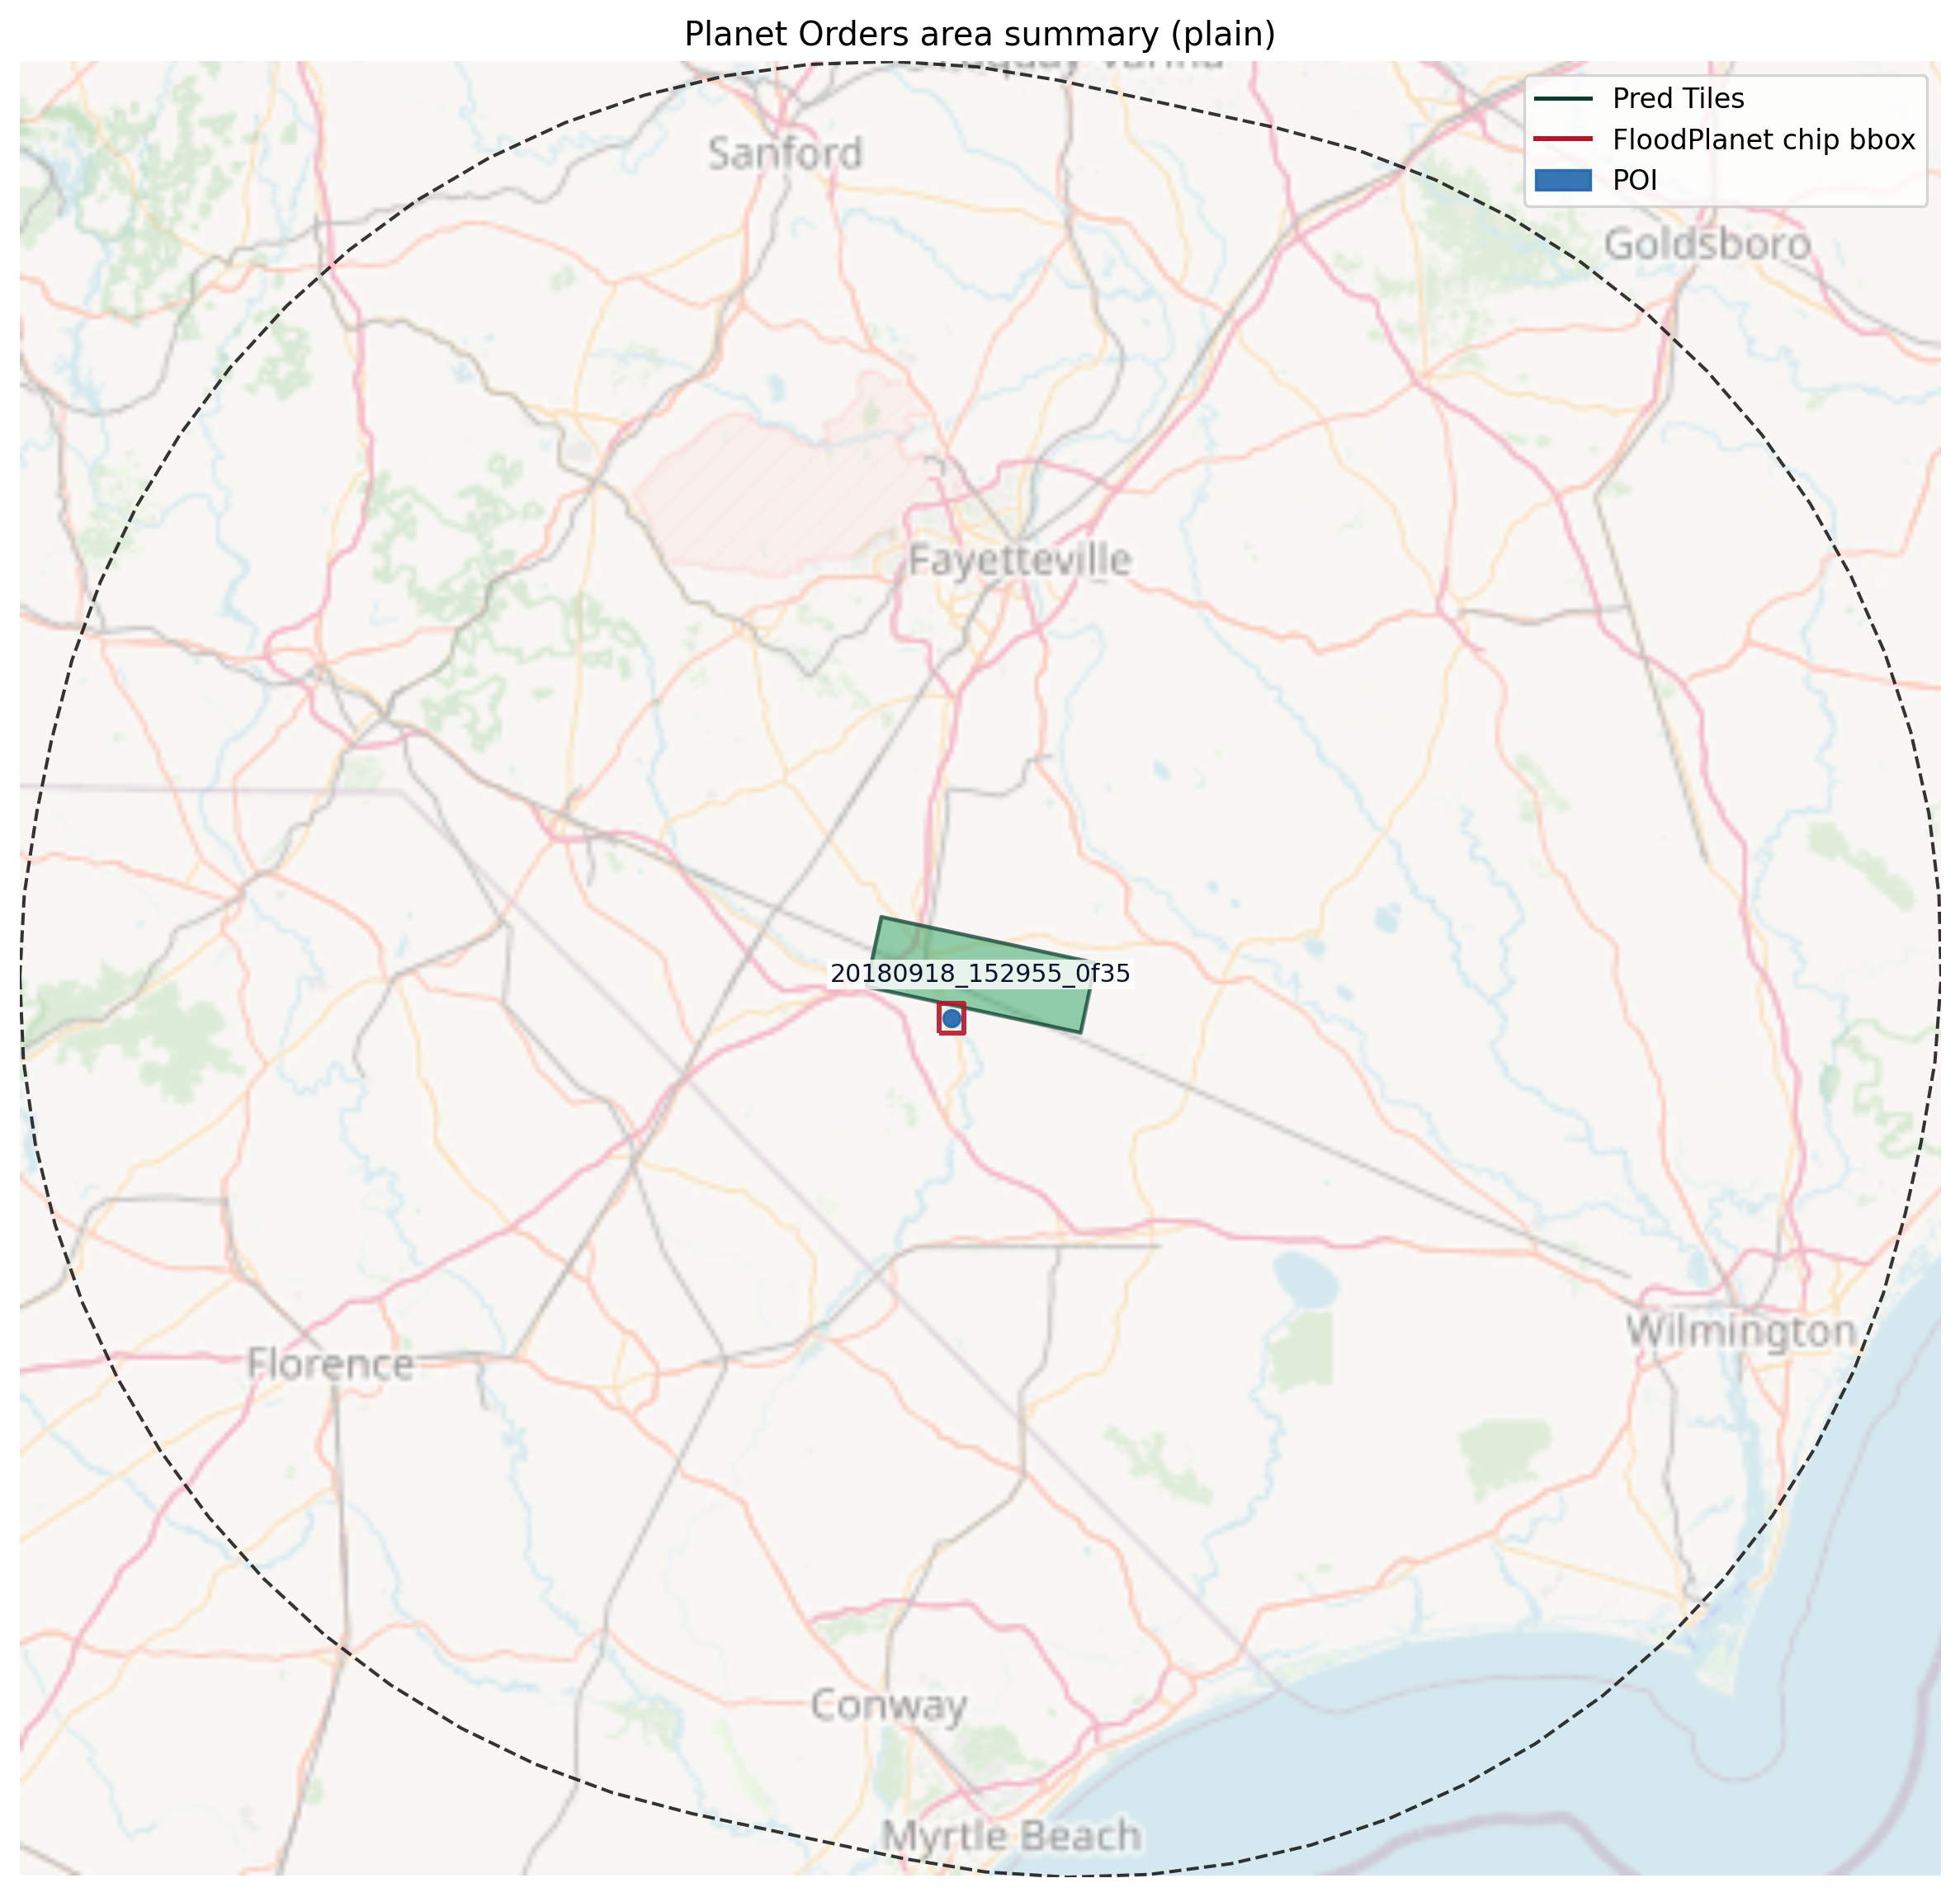

### 5D. Plain tile summary plot

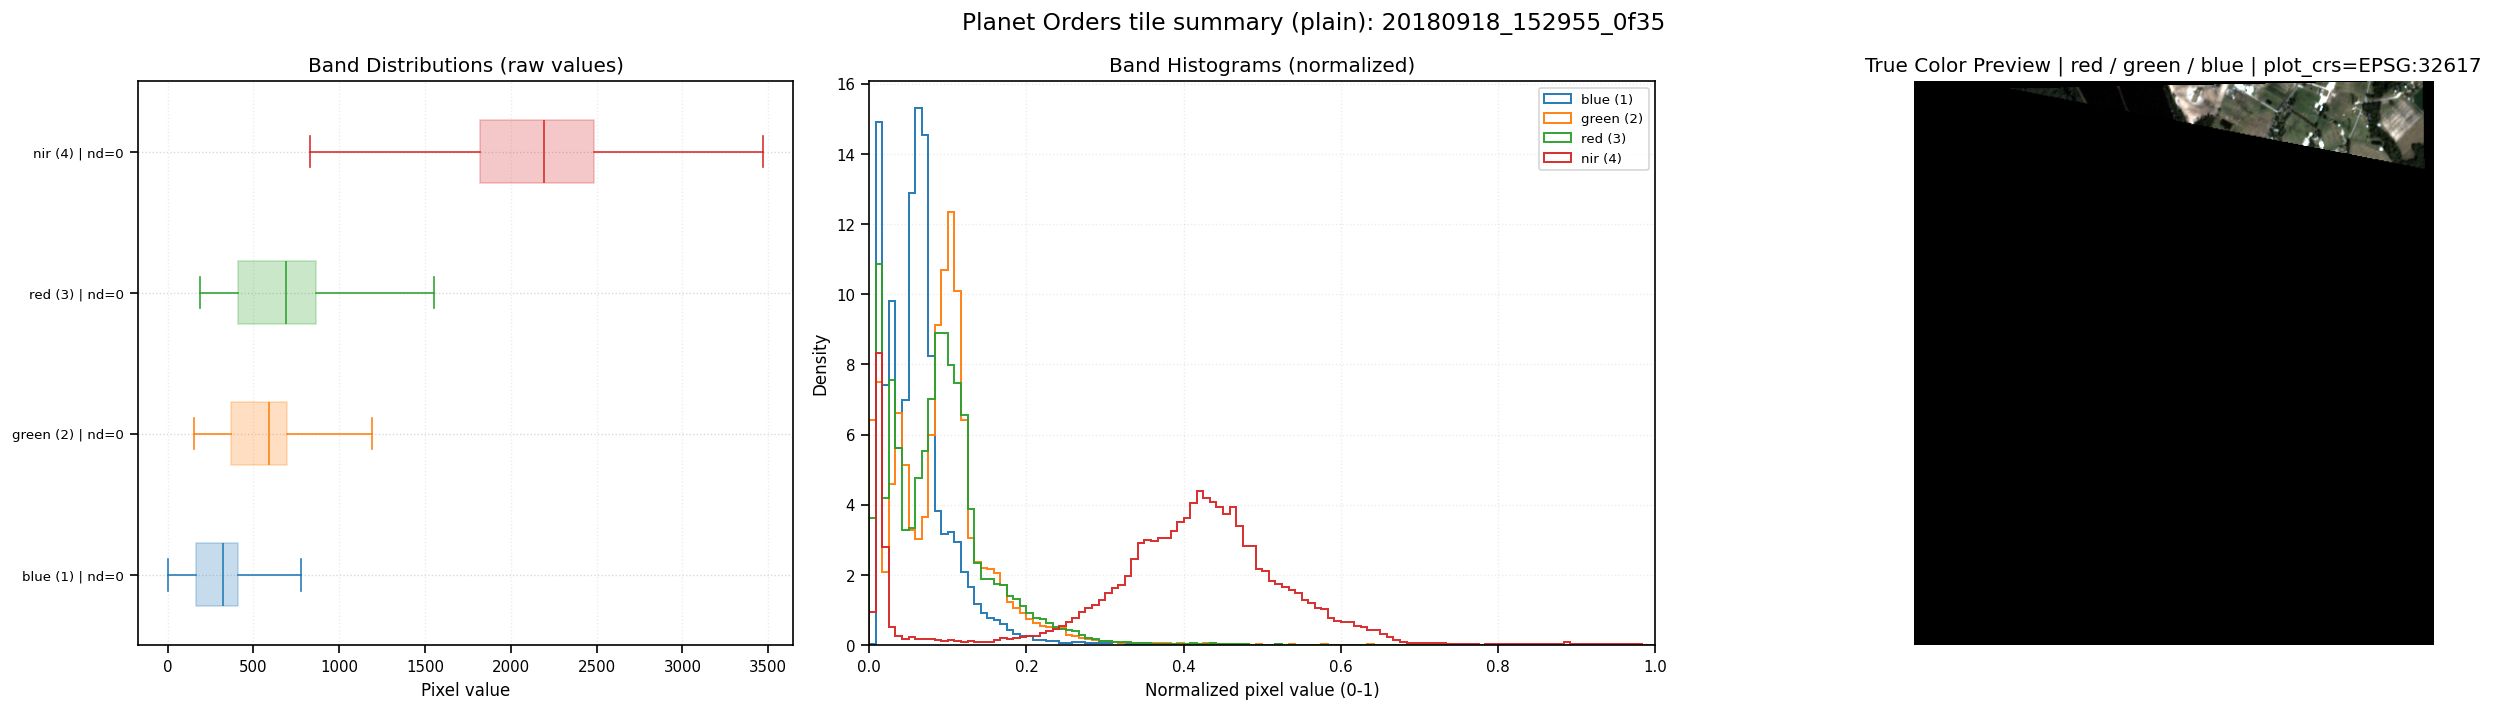

In [9]:

plain_order_result = await _fetch_mode(plain_query_result, use_harmonize=False)

display(Markdown("### 5A. Plain order summary"))
display(pd.DataFrame([{
    "mode": plain_order_result["mode_label"],
    "status": plain_order_result["status"],
    "order_id": plain_order_result["order_id"],
    "download_dir": str(plain_order_result["download_dir"].relative_to(REPO_ROOT)),
    "raster_count": len(plain_order_result["raster_paths"]),
}]))

display(Markdown("### 5B. Plain raster summary"))
with rasterio.open(plain_order_result["raster_paths"][0]) as ds:
    display(pd.DataFrame([{
        "mode": "plain",
        "path": str(plain_order_result["raster_paths"][0].relative_to(REPO_ROOT)),
        "bands": ds.count,
        "height": ds.height,
        "width": ds.width,
        "crs": str(ds.crs),
        "dtype": ",".join(ds.dtypes),
        "file_size_mb": round(plain_order_result["raster_paths"][0].stat().st_size / 1024**2, 3),
    }]))

display(Markdown("### 5C. Plain area summary plot"))
_ = _plot_area_summary(plain_query_result, mode_label="plain")

display(Markdown("### 5D. Plain tile summary plot"))
_ = _plot_tile_summary(plain_order_result["raster_paths"][0], tile_label=plain_order_result["item_id"], title_prefix="Planet Orders tile summary (plain)")



## 6. Harmonized Query And Plots

Reuse the same helpers for the harmonized path. The harmonized branch now stays to query, fetch, and tile summary only.


In [10]:

harmonized_query_result = await _query_planet_mode(mode_label="harmonized")

display(Markdown("### 6A. Harmonized query summary"))
display(harmonized_query_result["search_df"])

display(Markdown("### 6B. Harmonized selected scene"))
display(pd.DataFrame([harmonized_query_result["selected_row"].to_dict()]))

display(Markdown("### 6C. Harmonized selected asset inventory"))
display(pd.DataFrame({"asset_type": harmonized_query_result["selected_assets"]}))


### 6A. Harmonized query summary

,item_id,acquired_utc,time_delta_h,instrument,cloud_cover,clear_percent,has_target_asset
0,20180918_152955_0f35,2018-09-18T15:29:55.692972+00:00,8.501,PS2,0.02,98,True
1,20180918_152956_0f35,2018-09-18T15:29:56.742597+00:00,8.501,PS2,0.05,95,True
2,20180918_152115_104b,2018-09-18T15:21:15.322711+00:00,8.646,PS2,0.13,87,True
3,20180919_152007_100d,2018-09-19T15:20:07.483168+00:00,15.335,PS2,0.03,97,True
4,20180919_153017_1015,2018-09-19T15:30:17.813826+00:00,15.505,PS2,0.02,98,True
5,20180919_153018_1015,2018-09-19T15:30:18.859256+00:00,15.505,PS2,0.02,98,True


### 6B. Harmonized selected scene

,item_id,acquired_utc,time_delta_h,instrument,cloud_cover,clear_percent,has_target_asset
0,20180918_152955_0f35,2018-09-18T15:29:55.692972+00:00,8.501,PS2,0.02,98,True


### 6C. Harmonized selected asset inventory

,asset_type
0,basic_analytic_4b
1,basic_analytic_4b_rpc
2,basic_analytic_4b_xml
3,basic_udm2
4,ortho_analytic_3b
5,ortho_analytic_3b_xml
6,ortho_analytic_4b
7,ortho_analytic_4b_sr
8,ortho_analytic_4b_xml
9,ortho_udm2


Reusing harmonized files already on disk for 20180918_152955_0f35.


### 6D. Harmonized order summary

,mode,status,order_id,download_dir,raster_count
0,harmonized,reused_local,None,misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/harmonized,1


### 6E. Harmonized raster summary

,mode,path,bands,height,width,crs,dtype,file_size_mb
0,harmonized,misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/harmonized/ff24f3cc-dac8-42e3-bde2-d8875c2e2be8/PSScene/20180918_152955_0f35_3B_AnalyticMS_S...,4,1097,1012,EPSG:32617,"uint16,uint16,uint16,uint16",0.537


### 6F. Harmonized tile summary plot

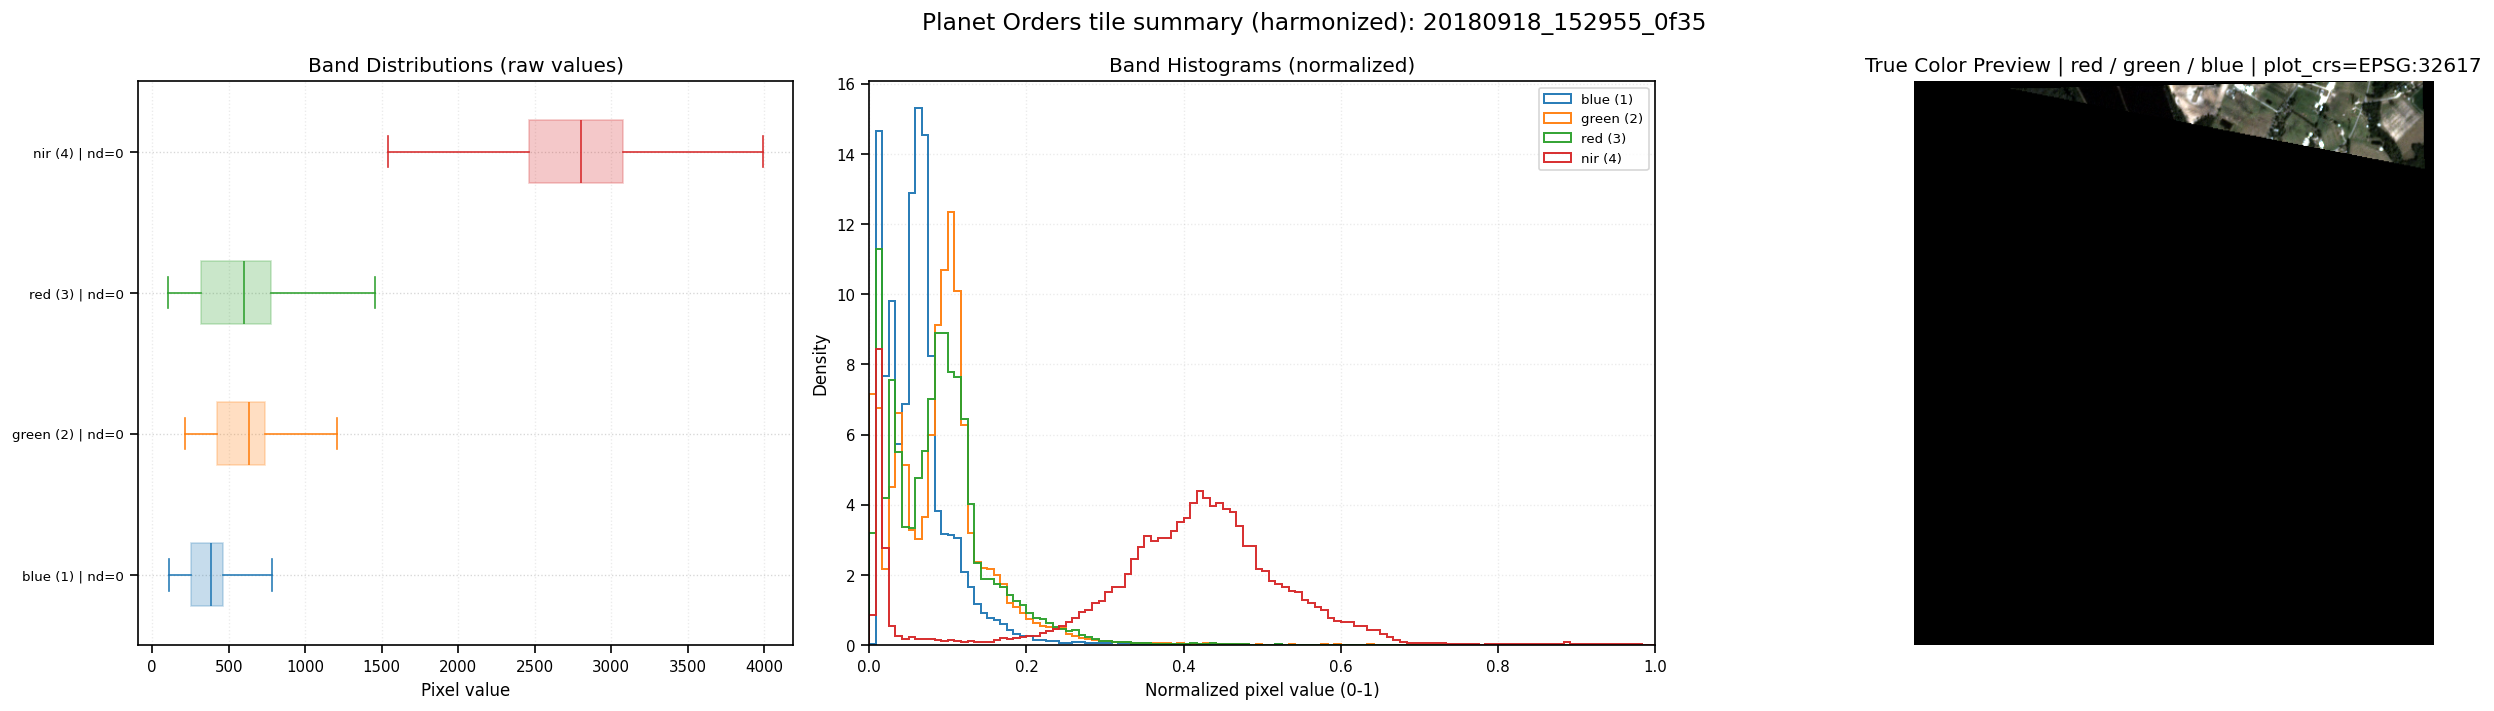

In [11]:

harmonized_order_result = await _fetch_mode(harmonized_query_result, use_harmonize=True)

display(Markdown("### 6D. Harmonized order summary"))
display(pd.DataFrame([{
    "mode": harmonized_order_result["mode_label"],
    "status": harmonized_order_result["status"],
    "order_id": harmonized_order_result["order_id"],
    "download_dir": str(harmonized_order_result["download_dir"].relative_to(REPO_ROOT)),
    "raster_count": len(harmonized_order_result["raster_paths"]),
}]))

display(Markdown("### 6E. Harmonized raster summary"))
with rasterio.open(harmonized_order_result["raster_paths"][0]) as ds:
    display(pd.DataFrame([{
        "mode": "harmonized",
        "path": str(harmonized_order_result["raster_paths"][0].relative_to(REPO_ROOT)),
        "bands": ds.count,
        "height": ds.height,
        "width": ds.width,
        "crs": str(ds.crs),
        "dtype": ",".join(ds.dtypes),
        "file_size_mb": round(harmonized_order_result["raster_paths"][0].stat().st_size / 1024**2, 3),
    }]))

display(Markdown("### 6F. Harmonized tile summary plot"))
_ = _plot_tile_summary(harmonized_order_result["raster_paths"][0], tile_label=harmonized_order_result["item_id"], title_prefix="Planet Orders tile summary (harmonized)")



## 7. Combined Comparison

Summarize the plain clip, harmonized clip, and matching FloodPlanet `PS` raster together, then render the combined comparison figure with top-row distribution panels and bottom-row RGB previews.


In [12]:
def _plot_three_way_summary(plain_fp: Path, harmonized_fp: Path, floodplanet_fp: Path, floodplanet_label: str):
    """Plot plain, harmonized, and FloodPlanet distributions plus RGB previews."""
    series_l = [
        {"label": "plain", "raster_fp": plain_fp, "linestyle": "-", "offset": -0.24, "fill": True, "alpha": 0.40},
        {"label": "harmonized", "raster_fp": harmonized_fp, "linestyle": "--", "offset": 0.00, "fill": False, "alpha": 1.00},
        {"label": floodplanet_label, "raster_fp": floodplanet_fp, "linestyle": ":", "offset": 0.24, "fill": False, "alpha": 1.00},
    ]
    color_l = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a", "#66a61e", "#e6ab02", "#a6761d", "#666666"]

    band_label_l = None
    sample_d = {}
    for series in series_l:
        with rasterio.open(series["raster_fp"]) as ds:
            current_band_label_l = _band_label_l(ds)
            if band_label_l is None:
                band_label_l = current_band_label_l
            assert len(current_band_label_l) == len(band_label_l), f"Band-count mismatch for {series['label']}"
            rng = np.random.default_rng(42)
            for band_i, band_label in enumerate(band_label_l, start=1):
                values = ds.read(band_i, masked=True).compressed().astype("float32", copy=False)
                if values.size > PLOT_D["max_points_per_band"]:
                    values = rng.choice(values, size=PLOT_D["max_points_per_band"], replace=False)
                sample_d.setdefault(band_label, {})[series["label"]] = {
                    "raw": values,
                    "norm": _normalize_band_values(values),
                }

    fig = plt.figure(figsize=(20, 12), dpi=120)
    gs = fig.add_gridspec(2, 6, height_ratios=[1.0, 1.05], hspace=0.35, wspace=0.35)
    ax_box = fig.add_subplot(gs[0, 0:3])
    ax_hist = fig.add_subplot(gs[0, 3:6])
    ax_rgb_plain = fig.add_subplot(gs[1, 0:2])
    ax_rgb_harmonized = fig.add_subplot(gs[1, 2:4])
    ax_rgb_floodplanet = fig.add_subplot(gs[1, 4:6])

    box_width = 0.20
    for band_idx, band_label in enumerate(band_label_l, start=1):
        color = color_l[(band_idx - 1) % len(color_l)]
        for series in series_l:
            sample = sample_d[band_label][series["label"]]
            box = ax_box.boxplot(
                [sample["raw"]],
                positions=[band_idx + series["offset"]],
                widths=box_width,
                patch_artist=True,
                showfliers=False,
                manage_ticks=False,
            )
            for patch in box["boxes"]:
                if series["fill"]:
                    patch.set(facecolor=color, alpha=series["alpha"], edgecolor=color, linestyle=series["linestyle"])
                else:
                    patch.set(facecolor="white", alpha=series["alpha"], edgecolor=color, linestyle=series["linestyle"], linewidth=1.5)
            for key in ["medians", "whiskers", "caps"]:
                for line in box[key]:
                    line.set(color=color, linestyle=series["linestyle"], linewidth=1.2)

            ax_hist.hist(
                sample["norm"],
                bins=PLOT_D["bins"],
                density=True,
                histtype="step",
                linewidth=1.3,
                linestyle=series["linestyle"],
                color=color,
                label=f"{series['label']} {band_label}",
            )

    ax_box.set_xticks(range(1, len(band_label_l) + 1))
    ax_box.set_xticklabels(band_label_l)
    ax_box.set_title("Grouped band box plots")
    ax_box.set_xlabel("Band")
    ax_box.set_ylabel("Reflectance DN")
    ax_box.grid(axis="y", alpha=0.25)
    ax_box.plot([], [], color="#444444", linewidth=1.8, linestyle="-", label="plain")
    ax_box.plot([], [], color="#444444", linewidth=1.8, linestyle="--", label="harmonized")
    ax_box.plot([], [], color="#444444", linewidth=1.8, linestyle=":", label=floodplanet_label)
    ax_box.legend(loc="best")

    ax_hist.set_title("Normalized band histograms")
    ax_hist.set_xlabel("Band-normalized pixel value (0-1)")
    ax_hist.set_ylabel("Density")
    ax_hist.set_xlim(0.0, 1.0)
    ax_hist.grid(alpha=0.25)
    ax_hist.legend(loc="best", ncols=3, fontsize=8)

    rgb_axes = [
        (ax_rgb_plain, plain_fp, "plain RGB"),
        (ax_rgb_harmonized, harmonized_fp, "harmonized RGB"),
        (ax_rgb_floodplanet, floodplanet_fp, f"{floodplanet_label} RGB"),
    ]
    for ax, raster_fp, title in rgb_axes:
        ax.imshow(_read_rgb_preview(raster_fp, max_side=PLOT_D["max_preview_side"]))
        ax.set_title(title)
        ax.set_axis_off()

    fig.suptitle(f"Plain vs harmonized vs FloodPlanet reference: {SEARCH_D['chip_id']}")
    plt.show()
    return fig


### 7A. Mode comparison

,mode,status,order_id,download_dir,raster_count
0,plain,reused_local,None,misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/plain,1
1,harmonized,reused_local,None,misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/harmonized,1
2,floodplanet_reference,external_reference,None,/home/cefect/LS/10_IO/2501_NSFc/zhangFloodPlanet2025/US-Carolina/PS,1


### 7B. Raster comparison

,mode,path,bands,height,width,crs,dtype,file_size_mb
0,plain,misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/plain/62231777-c370-4693-bf64-c9f6c755f26d/PSScene/20180918_152955_0f35_3B_AnalyticMS_SR_cli...,4,1097,1012,EPSG:32617,"uint16,uint16,uint16,uint16",0.544
1,harmonized,misc/proof_of_concept/planet_sdk_orders_poc_downloads/FLO_40_23/harmonized/ff24f3cc-dac8-42e3-bde2-d8875c2e2be8/PSScene/20180918_152955_0f35_3B_AnalyticMS_S...,4,1097,1012,EPSG:32617,"uint16,uint16,uint16,uint16",0.537
2,floodplanet_reference,/home/cefect/LS/10_IO/2501_NSFc/zhangFloodPlanet2025/US-Carolina/PS/FLO_40_23.tif,4,1024,1024,EPSG:4326,"uint16,uint16,uint16,uint16",8.006


### 7C. Plain vs harmonized vs FloodPlanet plot

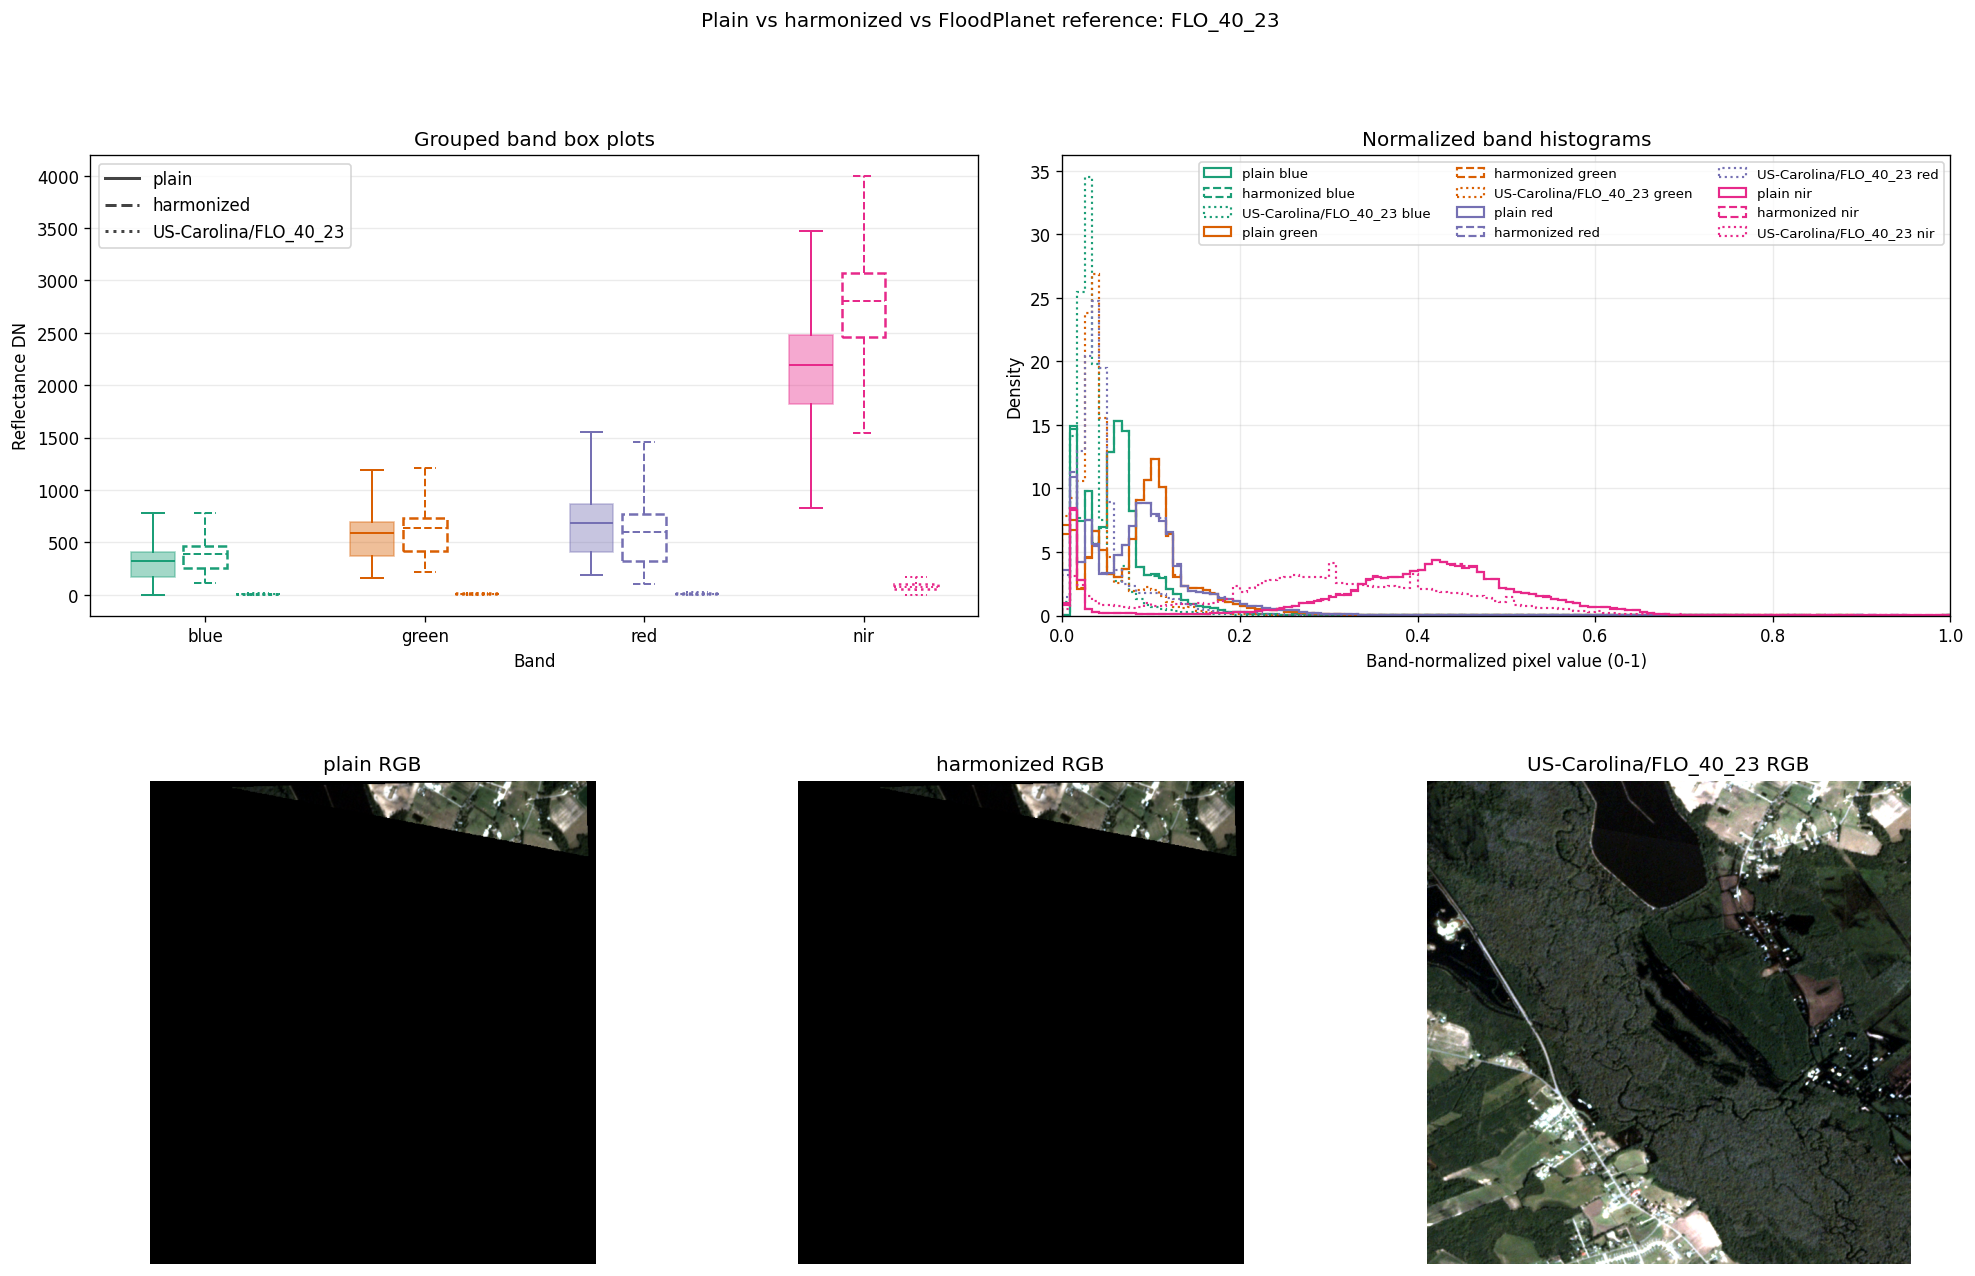

In [13]:

mode_summary_df = pd.DataFrame([
    {
        "mode": plain_order_result["mode_label"],
        "status": plain_order_result["status"],
        "order_id": plain_order_result["order_id"],
        "download_dir": str(plain_order_result["download_dir"].relative_to(REPO_ROOT)),
        "raster_count": len(plain_order_result["raster_paths"]),
    },
    {
        "mode": harmonized_order_result["mode_label"],
        "status": harmonized_order_result["status"],
        "order_id": harmonized_order_result["order_id"],
        "download_dir": str(harmonized_order_result["download_dir"].relative_to(REPO_ROOT)),
        "raster_count": len(harmonized_order_result["raster_paths"]),
    },
    {
        "mode": "floodplanet_reference",
        "status": "external_reference",
        "order_id": None,
        "download_dir": str(PATH_D["floodplanet_reference_fp"].parent),
        "raster_count": 1,
    },
])

raster_summary_rows = []
for mode_label, raster_fp in [
    ("plain", plain_order_result["raster_paths"][0]),
    ("harmonized", harmonized_order_result["raster_paths"][0]),
    ("floodplanet_reference", PATH_D["floodplanet_reference_fp"]),
]:
    with rasterio.open(raster_fp) as ds:
        raster_summary_rows.append({
            "mode": mode_label,
            "path": str(raster_fp if mode_label == "floodplanet_reference" else raster_fp.relative_to(REPO_ROOT)),
            "bands": ds.count,
            "height": ds.height,
            "width": ds.width,
            "crs": str(ds.crs),
            "dtype": ",".join(ds.dtypes),
            "file_size_mb": round(raster_fp.stat().st_size / 1024**2, 3),
        })
raster_summary_df = pd.DataFrame(raster_summary_rows)

display(Markdown("### 7A. Mode comparison"))
display(mode_summary_df)

display(Markdown("### 7B. Raster comparison"))
display(raster_summary_df)

display(Markdown("### 7C. Plain vs harmonized vs FloodPlanet plot"))
_ = _plot_three_way_summary(
    plain_order_result["raster_paths"][0],
    harmonized_order_result["raster_paths"][0],
    PATH_D["floodplanet_reference_fp"],
    floodplanet_label=f"{chip_row['Event']}/{chip_row['Chip_ID']}",
)



## 8. FloodPlanet Tile Summary

Render the matching FloodPlanet `PS` chip with the same diagnostics-style tile summary used for the order outputs.


### 8A. FloodPlanet tile summary plot

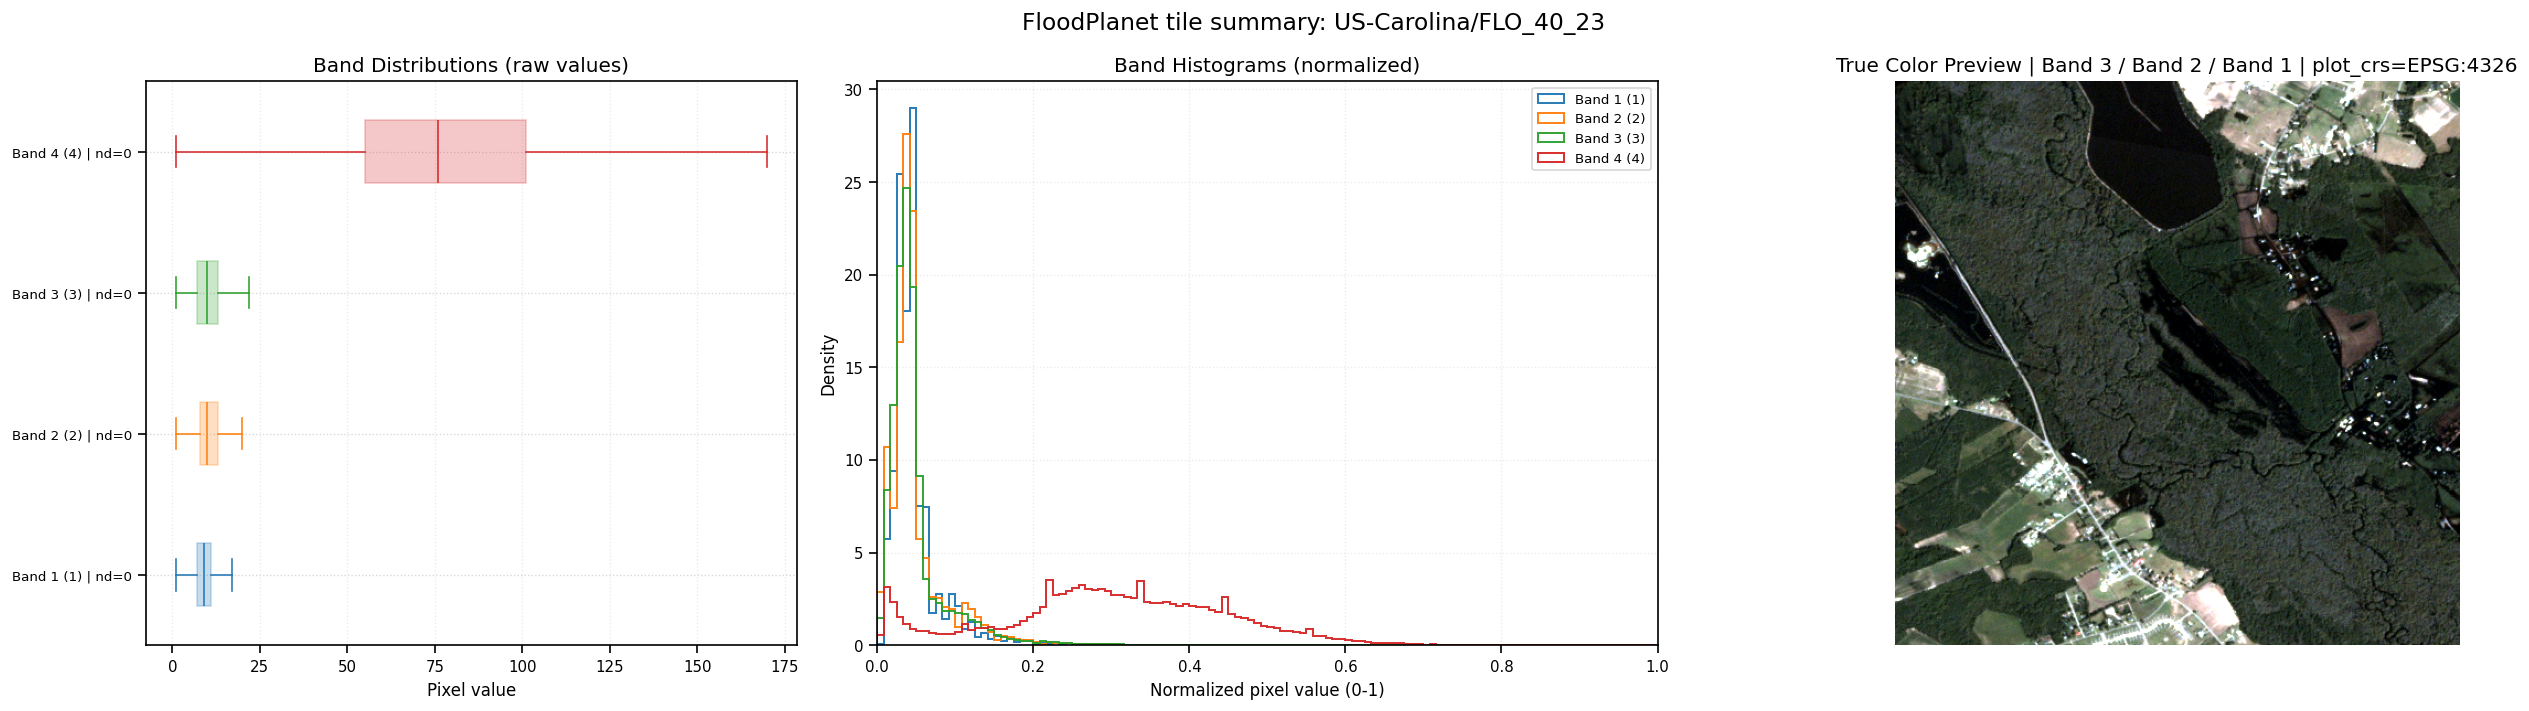

In [14]:

display(Markdown("### 8A. FloodPlanet tile summary plot"))
_ = _plot_tile_summary(
    PATH_D["floodplanet_reference_fp"],
    tile_label=f"{chip_row['Event']}/{chip_row['Chip_ID']}",
    title_prefix="FloodPlanet tile summary",
)
